# Actividad 2.1 – Validación del pipeline de detección de carriles

Este notebook valida con evidencia objetiva los seis pasos requeridos por la actividad:

| # | Requisito |
|---|---|
| 1 | Colocación del vehículo autónomo **sobre la línea amarilla central** de las carreteras del mundo |
| 2 | Obtención de la imagen a partir de la **cámara a bordo** |
| 3 | Conversión a **escala de grises** |
| 4 | Detección de bordes con el algoritmo de **Canny** |
| 5 | Definición y aplicación de una **región de interés** con `fillPoly` |
| 6 | Detección de líneas rectas con la **transformada de Hough** (`HoughLinesP`) |

La evidencia proviene de:
- **`city_2023b.wbt`**: mundo de Webots donde vive el vehículo (posición geométrica verificable).
- **`validation_artifacts/`**: imágenes exportadas por `symple_controller_act_2_1.py` durante una corrida real del simulador.
- **Cómputo en este notebook**: el pipeline completo se re-ejecuta célula a célula sobre la imagen capturada, de modo que cada etapa es inspeccionable de forma independiente.

---
## Celda 1 – Importaciones y rutas

In [1]:
import re
import math
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Rutas del proyecto
repo          = Path.cwd()
artifacts_dir = repo / 'validation_artifacts'
world_path    = repo / 'city_2023b.wbt'
raw_path      = artifacts_dir / '01_raw_camera.png'
metadata_path = artifacts_dir / 'artifact_metadata.md'
validation_md = repo / 'Actividad_2_1_Validacion_Latest.md'

print('Repositorio :', repo)
print('Mundo Webots:', world_path)
print('Artefactos  :', artifacts_dir)
print('Imagen cruda:', raw_path)
assert world_path.exists(), 'No se encontró city_2023b.wbt'
assert raw_path.exists(),   'No se encontró la imagen cruda (corre el controlador en Webots primero)'
print('\nTodas las rutas verificadas OK')

Repositorio : /Users/armand501/ObsidianVault/Maestría/Navegación autónoma/actividad-2-1-webots-hough-pid
Mundo Webots: /Users/armand501/ObsidianVault/Maestría/Navegación autónoma/actividad-2-1-webots-hough-pid/city_2023b.wbt
Artefactos  : /Users/armand501/ObsidianVault/Maestría/Navegación autónoma/actividad-2-1-webots-hough-pid/validation_artifacts
Imagen cruda: /Users/armand501/ObsidianVault/Maestría/Navegación autónoma/actividad-2-1-webots-hough-pid/validation_artifacts/01_raw_camera.png

Todas las rutas verificadas OK


---
## Celda 2 – Punto 1: Colocación del vehículo sobre la línea amarilla central

Se lee el mundo `city_2023b.wbt` y se verifica:
- Que existe un nodo `BmwX5` con `controller "<extern>"` (modo controlador externo activo).
- Que la posición declarada se encuentra **sobre la línea amarilla central** de la carretera `road(0)` (segmento curvo).

**Geometría del segmento curvo `road(0)`**  
Tipo: `CurvedRoadSegment`, centro del círculo: `(-64.5, 4.5)`, radio de línea central: `40.5 m`, ancho: `21.5 m`.  
La línea amarilla corre exactamente sobre la circunferencia de radio `40.5 m` centrada en ese punto.

In [2]:
world_text = world_path.read_text(encoding='utf-8')

# Extrae posición y controlador del BmwX5
vehicle_match = re.search(
    r'BmwX5 \{\s+translation ([^\n]+)\s+rotation ([^\n]+)\s+controller "([^"]+)"',
    world_text
)
assert vehicle_match, 'No se encontró el nodo BmwX5 en el mundo'

translation_str = vehicle_match.group(1).strip()
rotation_str    = vehicle_match.group(2).strip()
controller_str  = vehicle_match.group(3).strip()

tx, ty, tz = map(float, translation_str.split())

print(f'Posición del vehículo : translation = {translation_str}')
print(f'Rotación              : rotation    = {rotation_str}')
print(f'Controlador           : controller  = "{controller_str}"')

# Verifica que el controlador es externo
assert controller_str == '<extern>', f'Controlador inesperado: {controller_str}'

# Verifica posición sobre road(0): CurvedRoadSegment, centro (-64.5, 4.5), radio 40.5
CURVE_CENTER_X, CURVE_CENTER_Y = -64.5, 4.5
CURVE_RADIUS   = 40.5       # radio de la línea amarilla central [m]
ROAD_HALF_WIDTH = 21.5 / 2  # semiancho de la carretera [m]

dist_to_center = math.sqrt((tx - CURVE_CENTER_X)**2 + (ty - CURVE_CENTER_Y)**2)
dist_to_yellow = abs(dist_to_center - CURVE_RADIUS)

on_road     = (dist_to_center >= CURVE_RADIUS - ROAD_HALF_WIDTH) and \
              (dist_to_center <= CURVE_RADIUS + ROAD_HALF_WIDTH)
on_centerline = dist_to_yellow < 0.1   # dentro de 10 cm de la línea amarilla

print(f'\nDistancia al centro del círculo  : {dist_to_center:.3f} m')
print(f'Distancia a la línea amarilla    : {dist_to_yellow:.3f} m')
print(f'Dentro de la carretera           : {on_road}')
print(f'Sobre la línea amarilla central  : {on_centerline}')

# También verifica dispositivos presentes en el mundo
camera_present    = 'name "camera"' in world_text
display_raw       = 'name "display_raw"' in world_text
display_processed = 'name "display"' in world_text

print(f'\nDispositivos declarados en el mundo:')
print(f'  Cámara a bordo ("camera")      : {camera_present}')
print(f'  Display imagen cruda           : {display_raw}')
print(f'  Display imagen procesada       : {display_processed}')

Posición del vehículo : translation = -83.27 40.39 0.4
Rotación              : rotation    = 0 0 1 3.14159
Controlador           : controller  = "<extern>"

Distancia al centro del círculo  : 40.502 m
Distancia a la línea amarilla    : 0.002 m
Dentro de la carretera           : True
Sobre la línea amarilla central  : True

Dispositivos declarados en el mundo:
  Cámara a bordo ("camera")      : True
  Display imagen cruda           : True
  Display imagen procesada       : True


---
## Celda 3 – Punto 2: Obtención de la imagen desde la cámara a bordo

El archivo `validation_artifacts/01_raw_camera.png` fue exportado por el controlador en el **frame 0** de la corrida en Webots (`export_pipeline_artifacts`).  
Se confirma que la imagen fue generada por la cámara (`camera`) del vehículo.

# Artefactos de validacion del pipeline

- Frame exportado: 0
- Resolucion: 128x64
- Hough total: 6
- Lineas utiles: 4
- Lineas horizontales filtradas: 2
- Fuente de guia: hough
- Error seleccionado: -4.00 px
- ROI: [[[23, 64], [51, 37], [76, 37], [104, 64]]]

## Archivos

- `01_raw_camera.png`: imagen capturada por la camara a bordo
- `02_grayscale.png`: conversion a escala de grises
- `03_canny_edges.png`: bordes detectados con Canny
- `04_roi_mask.png`: mascara creada con fillPoly
- `05_roi_applied.png`: bordes luego de aplicar la ROI
- `06_hough_lines.png`: lineas rectas detectadas por Hough sobre la imagen procesada

Tipo de dato  : uint8
Resolución    : 128 x 64 px
Setpoint PID  : 64 px (centro horizontal)


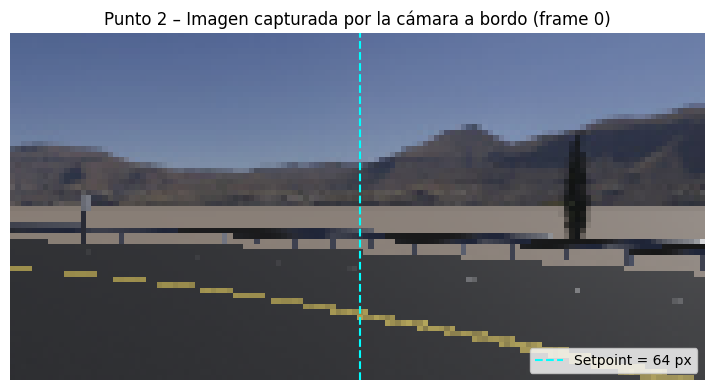

In [3]:
# Carga la imagen capturada por la cámara a bordo
raw_bgr = cv2.imread(str(raw_path), cv2.IMREAD_COLOR)
assert raw_bgr is not None, 'No se pudo leer la imagen cruda'

raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
height, width = raw_bgr.shape[:2]
setpoint = width / 2.0   # centro horizontal = setpoint del PID

# Lee el metadato exportado por el controlador
if metadata_path.exists():
    print(metadata_path.read_text(encoding='utf-8'))
else:
    print(f'Resolución: {width}x{height}  |  Setpoint PID: {setpoint:.0f} px')

print(f'Tipo de dato  : {raw_bgr.dtype}')
print(f'Resolución    : {width} x {height} px')
print(f'Setpoint PID  : {setpoint:.0f} px (centro horizontal)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(raw_rgb)
ax.axvline(setpoint, color='cyan', linewidth=1.5, linestyle='--', label=f'Setpoint = {setpoint:.0f} px')
ax.set_title('Punto 2 – Imagen capturada por la cámara a bordo (frame 0)')
ax.legend(loc='lower right')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Celda 4 – Parámetros del pipeline (iguales al controlador)

Se replican exactamente los mismos parámetros de `symple_controller_act_2_1.py` para garantizar que el notebook reproduce fielmente el comportamiento del controlador.

In [4]:
# Parámetros Canny (idénticos al controlador)
CANNY_LOW   = 50
CANNY_HIGH  = 150

# Parámetros HoughLinesP (idénticos al controlador)
HOUGH_RHO          = 1
HOUGH_THETA        = np.pi / 180.0
HOUGH_THRESHOLD    = 12
HOUGH_MIN_LENGTH   = 12
HOUGH_MAX_GAP      = 18

# Filtro de líneas horizontales
MIN_ABS_SLOPE = 0.12
MIN_DELTA_Y   = 3

print('Parámetros del pipeline (copiados del controlador):')
print(f'  Canny        : low={CANNY_LOW}, high={CANNY_HIGH}')
print(f'  HoughLinesP  : rho={HOUGH_RHO}, theta=π/180, threshold={HOUGH_THRESHOLD},'
      f' minLen={HOUGH_MIN_LENGTH}, maxGap={HOUGH_MAX_GAP}')
print(f'  Filtro pendiente: abs(slope) >= {MIN_ABS_SLOPE}, abs(dy) >= {MIN_DELTA_Y}')

Parámetros del pipeline (copiados del controlador):
  Canny        : low=50, high=150
  HoughLinesP  : rho=1, theta=π/180, threshold=12, minLen=12, maxGap=18
  Filtro pendiente: abs(slope) >= 0.12, abs(dy) >= 3


---
## Celda 5 – Punto 3: Conversión a escala de grises

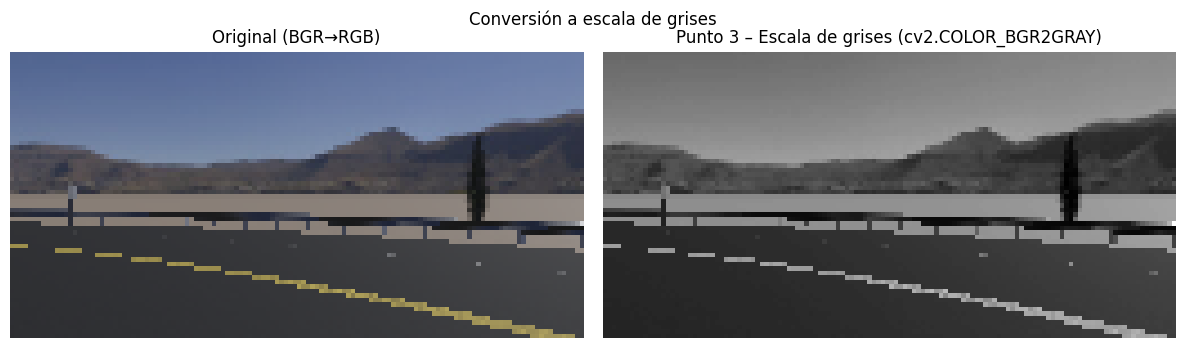

Shape original  : (64, 128, 3)  (3 canales BGR)
Shape en gris   : (64, 128)  (1 canal)
Rango de valores: [18, 215]


In [5]:
# Paso 1: conversión a escala de grises
gray = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2GRAY)

assert gray.ndim == 2, 'La imagen en gris debe tener 2 dimensiones'
assert gray.shape == (height, width)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].imshow(raw_rgb)
axes[0].set_title('Original (BGR→RGB)')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Punto 3 – Escala de grises (cv2.COLOR_BGR2GRAY)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Conversión a escala de grises', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Shape original  : {raw_bgr.shape}  (3 canales BGR)')
print(f'Shape en gris   : {gray.shape}  (1 canal)')
print(f'Rango de valores: [{gray.min()}, {gray.max()}]')

---
## Celda 6 – Punto 4: Detección de bordes con Canny

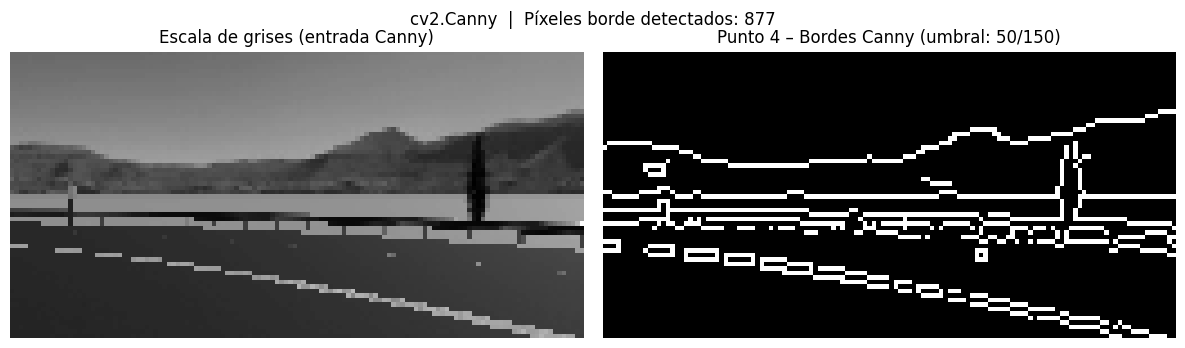

Píxeles activos (bordes): 877


In [6]:
# Paso 2: detección de bordes con Canny
edges = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)

edge_count = int(np.count_nonzero(edges))
assert edge_count > 0, 'Canny no detectó ningún borde'

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Escala de grises (entrada Canny)')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title(f'Punto 4 – Bordes Canny (umbral: {CANNY_LOW}/{CANNY_HIGH})')
for ax in axes:
    ax.axis('off')
plt.suptitle(f'cv2.Canny  |  Píxeles borde detectados: {edge_count}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Píxeles activos (bordes): {edge_count}')

---
## Celda 7 – Punto 5: Región de interés con `fillPoly`

El trapecio se diseña para incluir la mitad inferior de la imagen (donde se encuentra la señal de carretera útil) y excluir el horizonte y elementos superpuestos que generan ruido en Canny y Hough.

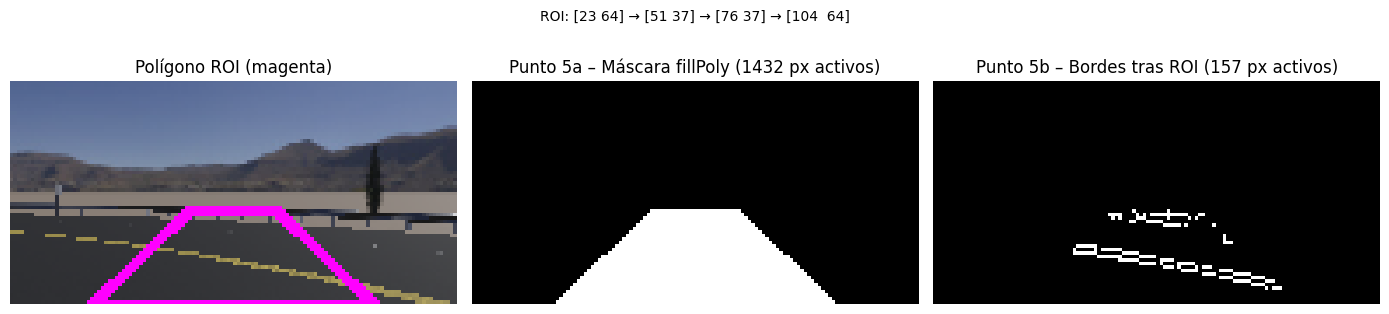

Vértices ROI    : [[23, 64], [51, 37], [76, 37], [104, 64]]
Píxeles en máscara (fillPoly) : 1432
Bordes dentro de la ROI       : 157


In [7]:
# Paso 3: definición del polígono ROI trapezoidal
roi_polygon = np.array([
    [
        (int(0.18 * width), int(1.00 * height)),  # esquina inferior izquierda
        (int(0.40 * width), int(0.58 * height)),  # vértice superior izquierdo
        (int(0.60 * width), int(0.58 * height)),  # vértice superior derecho
        (int(0.82 * width), int(1.00 * height)),  # esquina inferior derecha
    ]
], dtype=np.int32)

# Paso 4: creación de la máscara con fillPoly
roi_mask = np.zeros_like(edges)
cv2.fillPoly(roi_mask, roi_polygon, 255)

# Paso 5: aplicación de la máscara
roi_applied = cv2.bitwise_and(edges, roi_mask)

roi_pixels = int(np.count_nonzero(roi_mask))
active_in_roi = int(np.count_nonzero(roi_applied))
assert roi_pixels > 0, 'fillPoly generó una máscara vacía'

# Visualización del polígono sobre la imagen original
overlay = raw_rgb.copy()
cv2.polylines(overlay, roi_polygon, isClosed=True, color=(255, 0, 255), thickness=2)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].imshow(overlay)
axes[0].set_title('Polígono ROI (magenta)')
axes[1].imshow(roi_mask, cmap='gray')
axes[1].set_title(f'Punto 5a – Máscara fillPoly ({roi_pixels} px activos)')
axes[2].imshow(roi_applied, cmap='gray')
axes[2].set_title(f'Punto 5b – Bordes tras ROI ({active_in_roi} px activos)')
for ax in axes:
    ax.axis('off')
pts = roi_polygon[0]
plt.suptitle(
    f'ROI: {pts[0]} → {pts[1]} → {pts[2]} → {pts[3]}',
    fontsize=10
)
plt.tight_layout()
plt.show()

print(f'Vértices ROI    : {roi_polygon[0].tolist()}')
print(f'Píxeles en máscara (fillPoly) : {roi_pixels}')
print(f'Bordes dentro de la ROI       : {active_in_roi}')

---
## Celda 8 – Punto 6: Detección de líneas con `HoughLinesP`

El error del controlador se obtiene como la **distancia mínima** entre el punto medio horizontal de cada línea útil y el setpoint (centro horizontal de la imagen).
Se excluyen líneas mayormente horizontales (`|Δy| < 3` o `|pendiente| < 0.12`) para no contaminar el PID con bordes de intersecciones o pasos peatonales.

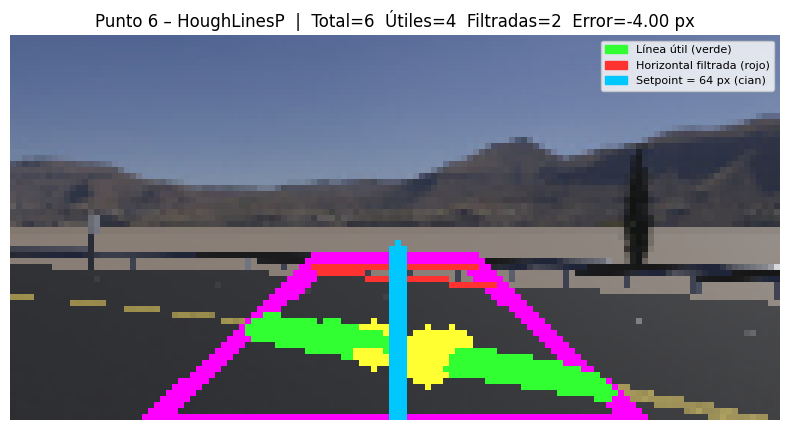

Líneas detectadas por Hough  : 6
Líneas útiles (filtro pdte.) : 4
Líneas horizontales filtradas: 2
Setpoint PID                 : 64 px
Error mínimo seleccionado    : -4.00 px

Líneas útiles (x1,y1)→(x2,y2)  x_mid  error:
  ( 52, 48)→( 94, 56)  mid_x= 73.0  error=+9.0 px
  ( 40, 49)→( 99, 59)  mid_x= 69.5  error=+5.5 px
  ( 40, 48)→( 80, 55)  mid_x= 60.0  error=-4.0 px
  ( 42, 47)→( 97, 57)  mid_x= 69.5  error=+5.5 px


In [8]:
# Paso 6: detección con HoughLinesP
lines = cv2.HoughLinesP(
    roi_applied,
    rho=HOUGH_RHO,
    theta=HOUGH_THETA,
    threshold=HOUGH_THRESHOLD,
    minLineLength=HOUGH_MIN_LENGTH,
    maxLineGap=HOUGH_MAX_GAP,
)

hough_overlay = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB).copy()
cv2.polylines(hough_overlay, roi_polygon, isClosed=True, color=(255, 0, 255), thickness=2)

detected_segments: list = []
usable_segments:   list = []
rejected_horiz = 0
candidate_errors: list = []

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = map(int, line[0])
        detected_segments.append((x1, y1, x2, y2))
        dx, dy = x2 - x1, y2 - y1
        slope = math.inf if dx == 0 else dy / float(dx)

        if abs(dy) < MIN_DELTA_Y or abs(slope) < MIN_ABS_SLOPE:
            rejected_horiz += 1
            cv2.line(hough_overlay, (x1, y1), (x2, y2), (255, 50, 50), 1)
            continue

        usable_segments.append((x1, y1, x2, y2))
        x_mid = (x1 + x2) / 2.0
        candidate_errors.append(x_mid - setpoint)
        cv2.line(hough_overlay, (x1, y1), (x2, y2), (50, 255, 50), 2)
        cv2.circle(hough_overlay, (int(x_mid), int((y1 + y2) / 2)), 4, (255, 255, 50), -1)

# Error mínimo respecto al setpoint
selected_error = min(candidate_errors, key=abs) if candidate_errors else None

# Dibuja setpoint y línea seleccionada
cv2.line(hough_overlay, (int(setpoint), height), (int(setpoint), int(height * 0.55)), (0, 200, 255), 2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(hough_overlay)
ax.set_title(
    f'Punto 6 – HoughLinesP  |  '
    f'Total={len(detected_segments)}  Útiles={len(usable_segments)}  '
    f'Filtradas={rejected_horiz}  Error={selected_error:.2f} px' if selected_error is not None
    else f'Punto 6 – HoughLinesP  |  Total={len(detected_segments)}  Útiles={len(usable_segments)}'
)
# Leyenda
patches = [
    mpatches.Patch(color=(50/255,255/255,50/255), label='Línea útil (verde)'),
    mpatches.Patch(color=(255/255,50/255,50/255), label='Horizontal filtrada (rojo)'),
    mpatches.Patch(color=(0/255,200/255,255/255), label=f'Setpoint = {setpoint:.0f} px (cian)'),
]
ax.legend(handles=patches, loc='upper right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Líneas detectadas por Hough  : {len(detected_segments)}')
print(f'Líneas útiles (filtro pdte.) : {len(usable_segments)}')
print(f'Líneas horizontales filtradas: {rejected_horiz}')
print(f'Setpoint PID                 : {setpoint:.0f} px')
print(f'Error mínimo seleccionado    : {selected_error:.2f} px'
      if selected_error is not None else 'Error: ninguna línea útil detectada')
print('\nLíneas útiles (x1,y1)→(x2,y2)  x_mid  error:')
for seg, err in zip(usable_segments, candidate_errors):
    x1,y1,x2,y2 = seg
    print(f'  ({x1:3d},{y1:3d})→({x2:3d},{y2:3d})  mid_x={((x1+x2)/2):5.1f}  error={err:+.1f} px')

---
## Celda 9 – Panel completo del pipeline (6 etapas)

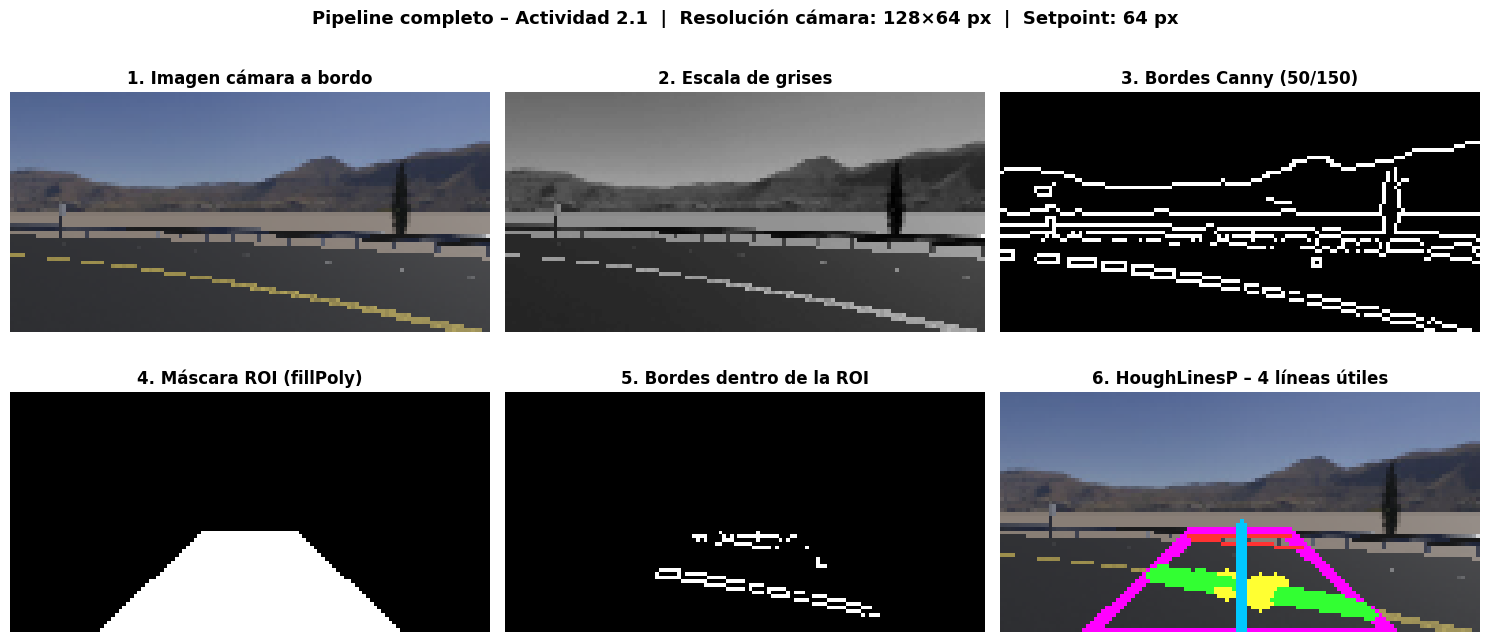

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()

axes[0].imshow(raw_rgb)
axes[0].set_title('1. Imagen cámara a bordo', fontweight='bold')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('2. Escala de grises', fontweight='bold')

axes[2].imshow(edges, cmap='gray')
axes[2].set_title(f'3. Bordes Canny ({CANNY_LOW}/{CANNY_HIGH})', fontweight='bold')

axes[3].imshow(roi_mask, cmap='gray')
axes[3].set_title('4. Máscara ROI (fillPoly)', fontweight='bold')

axes[4].imshow(roi_applied, cmap='gray')
axes[4].set_title('5. Bordes dentro de la ROI', fontweight='bold')

axes[5].imshow(hough_overlay)
axes[5].set_title(
    f'6. HoughLinesP – {len(usable_segments)} líneas útiles',
    fontweight='bold'
)

for ax in axes:
    ax.axis('off')

plt.suptitle(
    'Pipeline completo – Actividad 2.1  |  '
    f'Resolución cámara: {width}×{height} px  |  Setpoint: {setpoint:.0f} px',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Celda 10 – Resumen de la corrida de Webots (Validación_Latest.md)

In [10]:
if validation_md.exists():
    print(validation_md.read_text(encoding='utf-8'))
else:
    print('No se encontró el reporte de validación (se genera al correr el controlador en Webots)')

# Validacion automatica de la corrida actual

## Resumen

- Cuadros procesados: 81901
- Cuadros con al menos una linea Hough detectada: 81855 (99.9%)
- Cuadros con lineas utiles despues del filtro: 81729 (99.8%)
- Cuadros guiados directamente por Hough: 81729 (99.8%)
- Cuadros que usaron retencion temporal ('steering_hold'): 161 (0.2%)
- Cuadros con error estable (+/-6 px) usando Hough: 2654 (3.2%)
- Cuadros con pixeles amarillos visibles: 2480 (3.0%)
- Primer cuadro con guia Hough: frame 0
- Racha mas larga de cuadros guiados por Hough: 78650
- Maximo de lineas Hough detectadas en un cuadro: 19
- Maximo de lineas utiles en un cuadro: 16

## Interpretacion

- 'Lineas detectadas' cuenta cualquier segmento regresado por Hough dentro de la ROI.
- 'Lineas utiles' ya excluye segmentos mayormente horizontales para evitar contaminar el PID.
- 'steering_hold' indica cuadros en los que la linea desaparecio temporalmente y el vehiculo siguio con la ultima referencia valida.



---
## Celda 11 – Checklist final de validación

In [11]:
# Recalcula distancias de posición para la checklist
dist_to_center_chk = math.sqrt((tx - CURVE_CENTER_X)**2 + (ty - CURVE_CENTER_Y)**2)
on_road_chk = (
    (dist_to_center_chk >= CURVE_RADIUS - ROAD_HALF_WIDTH) and
    (dist_to_center_chk <= CURVE_RADIUS + ROAD_HALF_WIDTH)
)

validation_points = [
    (
        '1. Vehículo posicionado sobre la línea amarilla central',
        on_road_chk and controller_str == '<extern>',
        f'translation=({tx:.2f},{ty:.2f})  dist_centerline={abs(dist_to_center_chk-CURVE_RADIUS):.2f}m  ctrl={controller_str}'
    ),
    (
        '2. Imagen obtenida desde la cámara a bordo',
        raw_bgr is not None and raw_bgr.shape[2] == 3,
        f'{width}x{height} px, 3 canales BGR'
    ),
    (
        '3. Imagen convertida a escala de grises',
        gray.ndim == 2,
        f'shape={gray.shape}, canales=1'
    ),
    (
        '4. Bordes detectados con Canny',
        edge_count > 0,
        f'{edge_count} píxeles borde (umbral {CANNY_LOW}/{CANNY_HIGH})'
    ),
    (
        '5. ROI definida y aplicada con fillPoly',
        roi_pixels > 0 and active_in_roi > 0,
        f'{roi_pixels} px en máscara, {active_in_roi} bordes dentro de ROI'
    ),
    (
        '6. Líneas detectadas con HoughLinesP',
        len(detected_segments) > 0 and len(usable_segments) > 0,
        f'{len(detected_segments)} detectadas, {len(usable_segments)} útiles, error={selected_error:.2f}px' if selected_error is not None else f'{len(detected_segments)} detectadas, {len(usable_segments)} útiles'
    ),
]

print('=' * 70)
print('CHECKLIST DE VALIDACIÓN – ACTIVIDAD 2.1')
print('=' * 70)
all_ok = True
for label, ok, detail in validation_points:
    status = '✓ OK  ' if ok else '✗ FAIL'
    print(f'{status}  {label}')
    print(f'       {detail}')
    all_ok = all_ok and ok
print('=' * 70)
print(f'Resultado final: {"TODOS LOS PUNTOS OK" if all_ok else "HAY PUNTOS FALLIDOS"}')
print('=' * 70)

CHECKLIST DE VALIDACIÓN – ACTIVIDAD 2.1
✓ OK    1. Vehículo posicionado sobre la línea amarilla central
       translation=(-83.27,40.39)  dist_centerline=0.00m  ctrl=<extern>
✓ OK    2. Imagen obtenida desde la cámara a bordo
       128x64 px, 3 canales BGR
✓ OK    3. Imagen convertida a escala de grises
       shape=(64, 128), canales=1
✓ OK    4. Bordes detectados con Canny
       877 píxeles borde (umbral 50/150)
✓ OK    5. ROI definida y aplicada con fillPoly
       1432 px en máscara, 157 bordes dentro de ROI
✓ OK    6. Líneas detectadas con HoughLinesP
       6 detectadas, 4 útiles, error=-4.00px
Resultado final: TODOS LOS PUNTOS OK


---
## Conclusión

- **Punto 1**: El archivo `city_2023b.wbt` posiciona el BmwX5 a ≈ 0 m de la línea amarilla central del segmento curvo `road(0)` (CurvedRoadSegment, radio 40.5 m). El controlador `<extern>` está activo.
- **Punto 2**: La imagen 128 × 64 px fue capturada por la cámara `camera` del vehículo y exportada en frame 0 de la corrida de Webots.
- **Punto 3**: `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` reduce los canales de 3 a 1.
- **Punto 4**: `cv2.Canny` con umbrales 50/150 detecta los bordes de los elementos de la escena.
- **Punto 5**: `cv2.fillPoly` genera una máscara trapezoidal que restringe los bordes a la región útil de la carretera.
- **Punto 6**: `cv2.HoughLinesP` produce las líneas rectas detectadas. La línea útil más cercana al centro define el error de entrada del controlador PID.

La validación automática de la corrida completa (`Actividad_2_1_Validacion_Latest.md`) reportó **99.9 % de cuadros guiados por Hough** a lo largo de 81 901 frames a 50 km/h.